# [PDF Loader](https://python.langchain.com/docs/integrations/document_loaders/#pdfs)

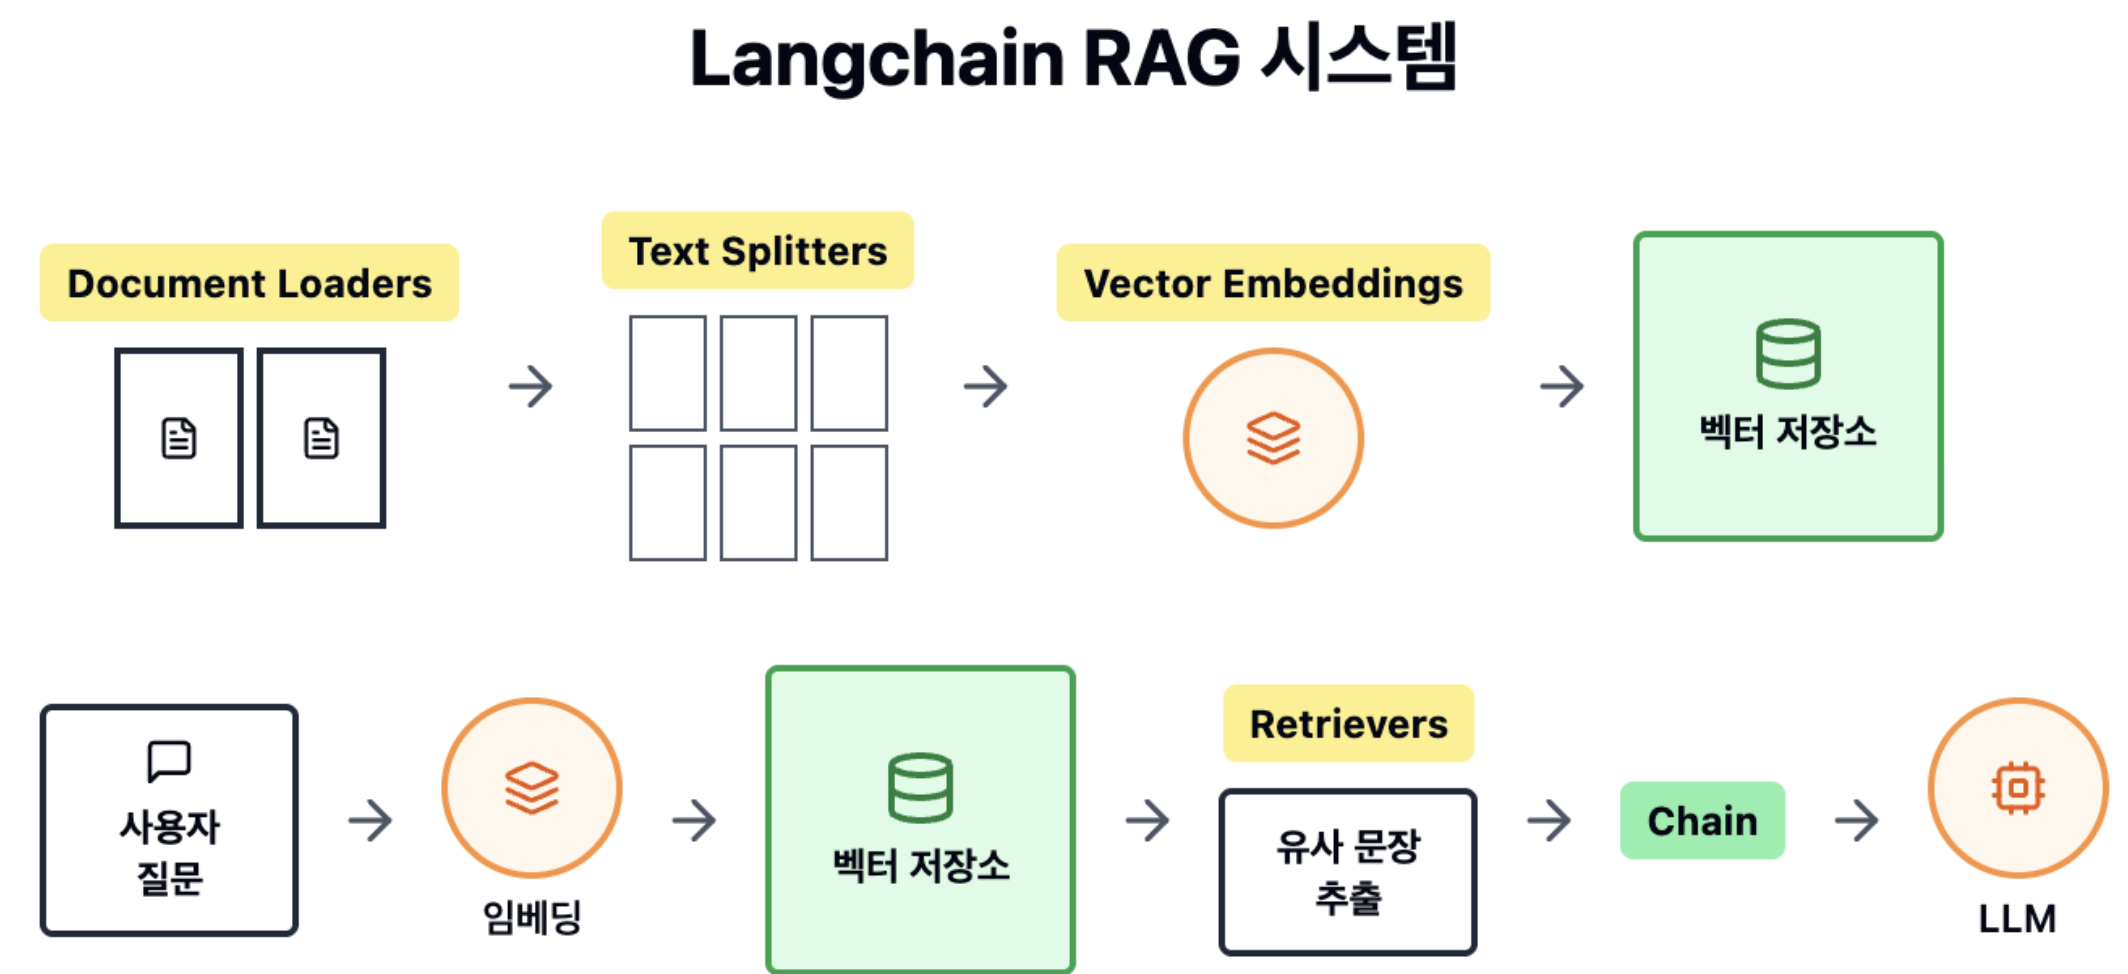

## PyPDFLoader:
- `특징`: 가장 기본적인 PDF 로더 중 하나로, pypdf 라이브러리를 사용합니다. 단순하고 깨끗한 텍스트 위주의 PDF에서 텍스트를 추출하는 데 효율적입니다. 각 페이지를 별도의 Document 객체로 로드합니다.
- `장점`: 사용이 간편하고, 빠른 텍스트 추출이 가능합니다. 파일 크기가 큰 경우에도 비교적 효율적입니다.
- `사용 예시`: 대부분의 일반적인 PDF 문서에서 텍스트를 추출할 때 적합합니다.

## PyMuPDFLoader (Fitz):
- `특징`: PyMuPDF 라이브러리를 기반으로 하며, 텍스트 추출뿐만 아니라 이미지, 주석 등 PDF의 다양한 정보를 가져오는 데 뛰어난 성능을 보여줍니다. 페이지별 접근이 용이하여 정교한 처리가 필요할 때 유용합니다.
- `장점`: 고해상도 이미지 처리, 복잡한 레이아웃 분석 등 고급 기능이 필요할 때 강점을 보입니다.
- `사용 예시`: 이미지나 도표가 많거나, 문서의 시각적인 요소도 분석해야 하는 경우에 좋습니다.

## UnstructuredPDFLoader:
- `특징`: Unstructured 라이브러리를 사용하여 PDF 파일의 구조를 분석하고 텍스트, 테이블, 이미지를 효율적으로 추출합니다. 비정형 데이터 처리에 강력하며, 문서의 레이아웃에 덜 의존적인 방식으로 작동합니다.
- `장점`: 스캔된 PDF나 복잡한 레이아웃을 가진 PDF에서 정확한 텍스트 및 구조 추출에 유용합니다.
- `사용 예시`: 스캔된 문서, 다양한 형식의 보고서 등 구조가 불규칙한 PDF에 적합합니다.

## PDFPlumberLoader:
- `특징`: PDFPlumber를 사용하여 PDF 파일의 텍스트와 테이블을 추출합니다. 각 페이지별 상세한 메타데이터를 제공하며, 테이블 데이터 추출에 특히 강점을 보입니다.
- `장점`: 테이블 데이터가 많은 PDF에서 테이블 구조를 유지하며 데이터를 추출하는 데 매우 효과적입니다.
- `사용 예시`: 재무 보고서, 데이터가 포함된 표가 많은 문서 등에서 테이블 정보를 정확하게 추출하고 싶을 때 좋습니다.

# 선택 가이드라인:
- 단순 텍스트 위주 PDF: `PyPDFLoader` 또는 `PyMuPDFLoader`
- 복잡한 레이아웃 또는 스캔된 PDF: `UnstructuredPDFLoader`, `AmazonTextractPDFLoader`
- 테이블 데이터 추출이 중요할 때: `PDFPlumberLoader`, `UnstructuredPDFLoader`, `AmazonTextractPDFLoader`
- 이미지/주석 등 시각적 요소 포함: `PyMuPDFLoader`

# 예제

## PDF 파일들

In [2]:
pdf_attention = "data/Attention Is All You Need.pdf"
pdf_bert = "data/BERT.pdf"
pdf_lg_aimers = "data/LG Aimers 4기 소개자료.pdf"

## pypdf
- `설명`: PyPDF2를 기반으로 PDF 문서의 텍스트를 추출합니다.
- `장점`: 빠르고 설치가 간편하며 대부분의 PDF에서 잘 작동.
- `단점`: 이미지 기반 PDF나 복잡한 레이아웃에서는 품질 저하 가능.

### [예제: PyPDFLoader](https://python.langchain.com/docs/integrations/document_loaders/pypdfloader/)

#### PyPDFLoader 파라미터 설명

| 파라미터 | 필수 여부 | 설명 | 예시 |
|---------|---------|------|------|
| `file_path` | 필수 | PDF 파일 경로 (로컬 파일 경로 또는 URL) | `"./document.pdf"` 또는 `"https://example.com/file.pdf"` |
| `extract_images` | 선택 | 이미지 추출 여부 (기본값: False) | `True` 또는 `False` |
| `password` | 선택 | 암호화된 PDF의 비밀번호 | `"mypassword123"` |

In [3]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader(
    file_path=pdf_lg_aimers,
    extract_images=False)

In [4]:
docs = loader.load()
print(f"PDF 파일의 페이지 수: {len(docs)}")

PDF 파일의 페이지 수: 7


#### 메타정보 추출

In [5]:
docs[0].metadata

{'producer': 'PyPDF',
 'creator': 'PyPDF',
 'creationdate': '2025-07-15T07:40:32+00:00',
 'moddate': '2025-07-15T07:40:32+00:00',
 'source': 'data/LG Aimers 4기 소개자료.pdf',
 'total_pages': 7,
 'page': 0,
 'page_label': '1'}

#### 텍스트 추출

In [6]:
print(docs[0].page_content)

LG AI연구원｜
LG Aimers 소개 자료


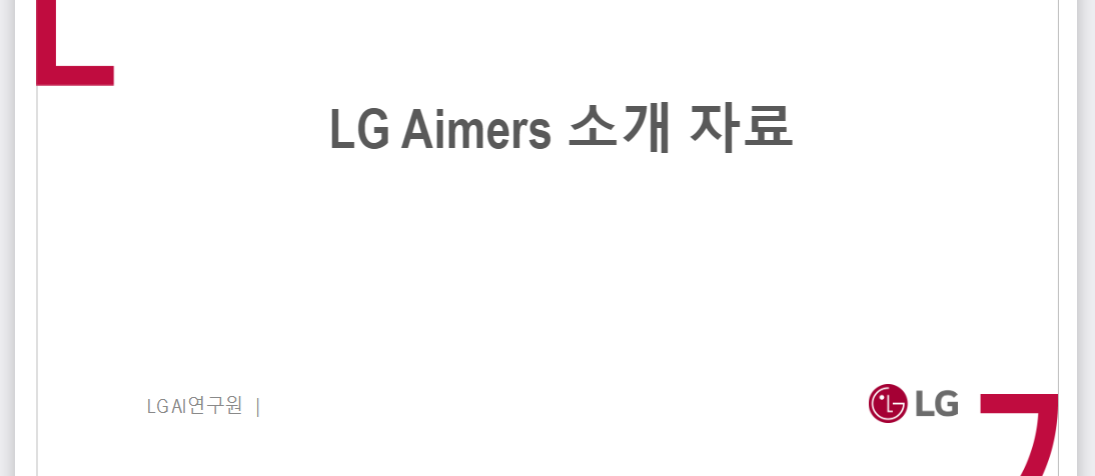

### [예제: pypdf](https://github.com/py-pdf/pypdf)

#### 메타정보 추출

In [7]:
from pypdf import PdfReader

# PDF 파일 열기
reader = PdfReader(pdf_attention)

# 메타데이터 가져오기
metadata = reader.metadata

# 출력
print("PDF 메타데이터:")
for key, value in metadata.items():
    print(f"{key}: {value}")

PDF 메타데이터:
/Author: 
/CreationDate: D:20240410211143Z
/Creator: LaTeX with hyperref
/Keywords: 
/ModDate: D:20240410211143Z
/PTEX.Fullbanner: This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5
/Producer: pdfTeX-1.40.25
/Subject: 
/Title: 
/Trapped: /False


#### 텍스트 추출

In [8]:
for i in reader.pages:
    print("="*50)
    # 페이지별 텍스트 추출 
    print(i.extract_text()[:300])
    break 

Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Par


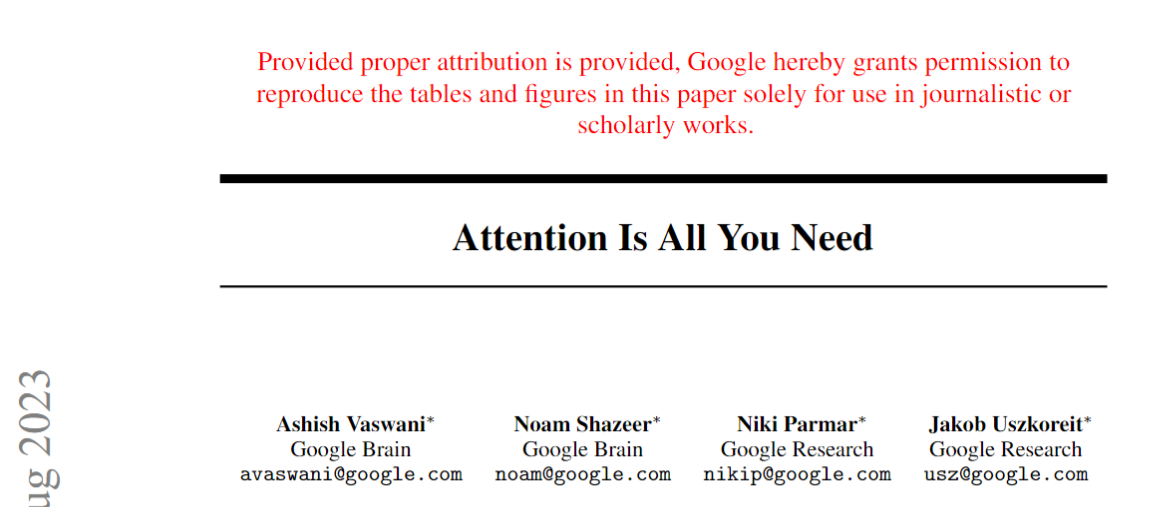

#### with Langchain Document

In [9]:
from langchain_core.documents import Document

###########################################
# 초기화 
###########################################
dict_metadata = dict(reader.metadata)
documents = []
count = 0

###########################################
# 페이지별 처리  
###########################################
for i, page in enumerate(reader.pages):
    # 메타이데이터 추가 
    dict_metadata['page_no'] = i+1

    ###########################################
    # 페이지별 이미지 추가   
    ###########################################
    dict_metadata['lst_image_file_names'] = []
    for image_file_object in page.images:

        # Open and write the image data
        image_names = image_file_object.name.split(".")
        image_file_name = f"{image_names[0]}_{str(count)}.{image_names[1]}"
        with open(image_file_name, "wb") as fp:
            fp.write(image_file_object.data)
            count += 1
            dict_metadata['lst_image_file_names'].append(image_file_name)

    ###########################################
    # 페이지별 document 추가   
    ###########################################
    documents.append(Document(
        page_content=page.extract_text(),   # 페이지별 텍스트 
        metadata=dict_metadata              # 페이지별 메타데이터
    ))

> 추출된 이미지 및 메타데이터 확인 

In [10]:
documents[2].metadata

{'/Author': '',
 '/CreationDate': 'D:20240410211143Z',
 '/Creator': 'LaTeX with hyperref',
 '/Keywords': '',
 '/ModDate': 'D:20240410211143Z',
 '/PTEX.Fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
 '/Producer': 'pdfTeX-1.40.25',
 '/Subject': '',
 '/Title': '',
 '/Trapped': '/False',
 'page_no': 3,
 'lst_image_file_names': ['Im1_0.png']}

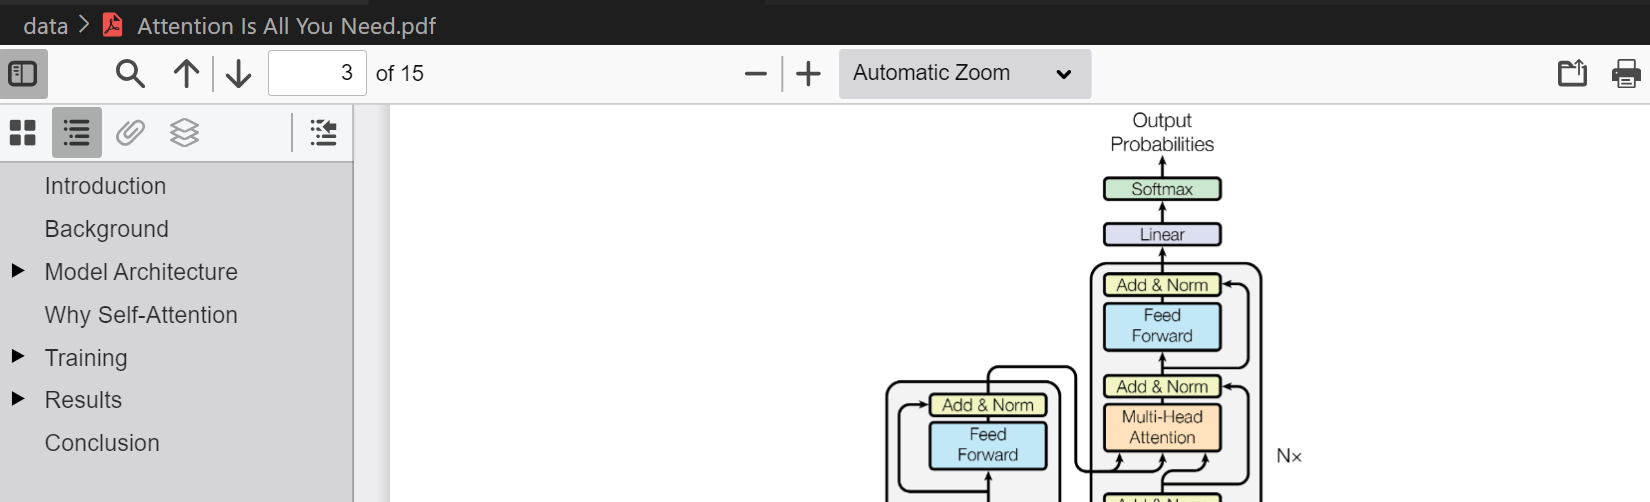

> 추출된 텍스트 확인 

In [27]:
print(documents[2].page_content[:300])

Figure 1: The Transformer - model architecture.
The Transformer follows this overall architecture using stacked self-attention and point-wise, fully
connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1,
respectively.
3.1 Encoder and Decoder Stacks
Encoder


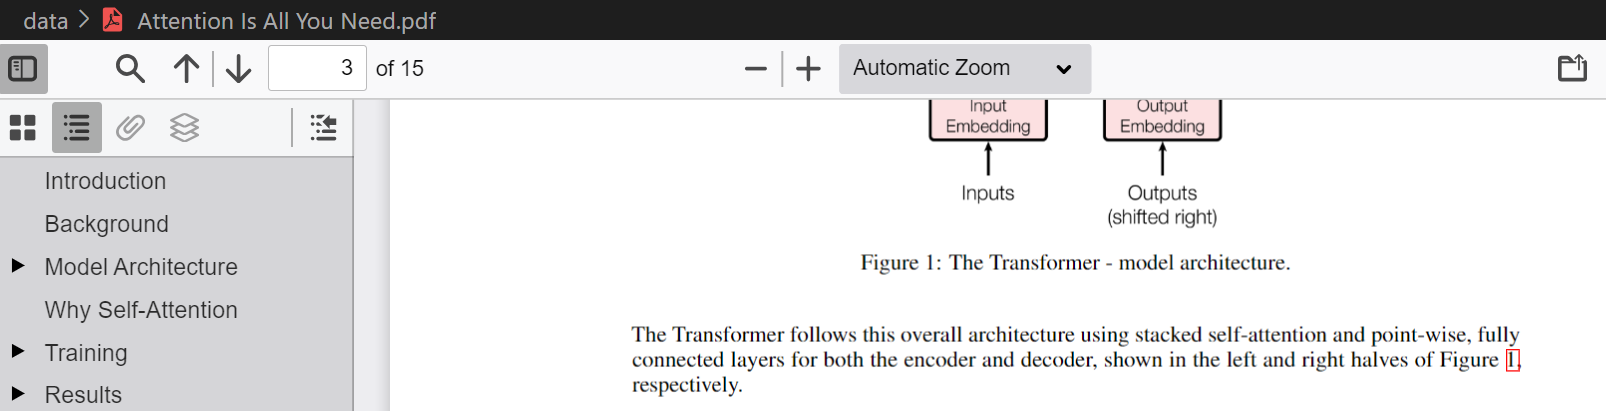

## pdfplumber
- `설명`: pdfplumber를 사용하여 PDF의 레이아웃 및 테이블 구조까지 고려해 텍스트를 추출.
- `장점`: 테이블 추출 정확도가 높고, 레이아웃 유지에 강함.
- `단점`: 속도가 느릴 수 있음.

### [PDFPlumberLoader](https://python.langchain.com/docs/integrations/document_loaders/pdfplumber/)

#### PyPDFLoader vs PDFPlumberLoader

| 특징 | PyPDFLoader | PDFPlumberLoader |
|------|-------------|------------------|
| **속도** | 빠름 | 상대적으로 느림 |
| **정확도** | 보통 | 높음 (표, 레이아웃 정확) |
| **표 추출** | 어려움 | 우수 |
| **레이아웃 보존** | 어려움 | 우수 |
| **복잡한 PDF** | 제한적 | 잘 처리함 |
| **사용 권장** | 단순한 PDF | 표/레이아웃이 중요한 PDF |

### 예제: PDFPlumberLoader

##### PDFPlumberLoader 파라미터 설명

| 파라미터 | 필수 여부 | 설명 | 예시 |
|---------|---------|------|------|
| `file_path` | 필수 | PDF 파일 경로 (로컬 파일 경로만 지원) | `"./document.pdf"` |
| `text_kwargs` | 선택 | pdfplumber의 extract_text() 메서드에 전달할 옵션 | `{"layout": True, "x_tolerance": 3}` |
| `extract_images` | 선택 | 이미지 추출 여부 (기본값: False) | `True` 또는 `False` |

> text_kwargs 주요 옵션

| 옵션 | 설명 | 기본값 |
|------|------|--------|
| `layout` | 원본 레이아웃 유지 (공백, 줄바꿈 보존) | `False` |
| `x_tolerance` | 같은 줄로 인식할 가로 간격 허용 오차 (픽셀) | `3` |
| `y_tolerance` | 같은 줄로 인식할 세로 간격 허용 오차 (픽셀) | `3` |
| `x_density` | 텍스트 추출 가로 해상도 | `7.25` |
| `y_density` | 텍스트 추출 세로 해상도 | `7.25` |

In [11]:
from langchain_community.document_loaders import PDFPlumberLoader

loader = PDFPlumberLoader(pdf_lg_aimers)

In [12]:
docs = loader.load()
len(docs)

7

#### 메타정보 추출 

In [13]:
docs[1].metadata

{'source': 'data/LG Aimers 4기 소개자료.pdf',
 'file_path': 'data/LG Aimers 4기 소개자료.pdf',
 'page': 1,
 'total_pages': 7,
 'CreationDate': "D:20250715074032+00'00'",
 'ModDate': "D:20250715074032+00'00'"}

#### 텍스트 추출

In [14]:
print(docs[1].page_content[:300])

1. LG Aimers 프로그램 개요
❑교육과 경험의 기회를 필요로 하는 청년들에게 양질의 AI교육을 온라인으로 제공하고, 기업의 실제 data를 다루며
실무를 경험할 수 있는 기회를 제공하기 위해 『온라인 AI전문가 과정(1개월)』 과 『AI 해커톤 (Hackathon)(1개월)』을
결합한 형태의 교육 프로그램
- 온라인 AI 교육 과정 : 국내 AI 전문가 (현업 전문가, 저명 교수)의 최신 AI 기법에 관한 온라인 강의(1개월)
• 온라인 초급 교육은 기초적인 프로그래밍데이터 처리에 관련된 내용들로써 외부 교육 콘텐츠를 활용(


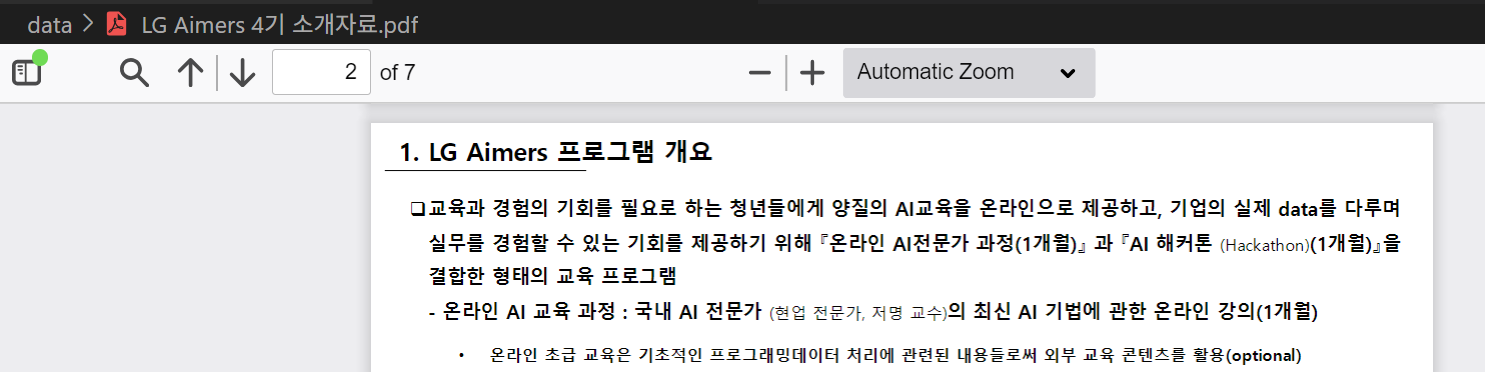

### [예제: pdfplumber](https://github.com/jsvine/pdfplumber)

In [15]:
import pdfplumber

#### 메타정보 추출

In [16]:
with pdfplumber.open(pdf_bert) as pdf:
    metadata = pdf.metadata
    print(metadata)

{'Author': '', 'CreationDate': 'D:20190528000751Z', 'Creator': 'LaTeX with hyperref package', 'Keywords': '', 'ModDate': 'D:20190528000751Z', 'PTEX.Fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.17 (TeX Live 2016) kpathsea version 6.2.2', 'Producer': 'pdfTeX-1.40.17', 'Subject': '', 'Title': '', 'Trapped': 'False'}


#### 텍스트 추출

In [17]:
with pdfplumber.open(pdf_bert) as pdf:
    text = pdf.pages[0].extract_text()
    print(text[:300])

BERT: Pre-training of Deep Bidirectional Transformers for
Language Understanding
JacobDevlin Ming-WeiChang KentonLee KristinaToutanova
GoogleAILanguage
{jacobdevlin,mingweichang,kentonl,kristout}@google.com
Abstract There are two existing strategies for apply-
ingpre-trainedlanguage representations 


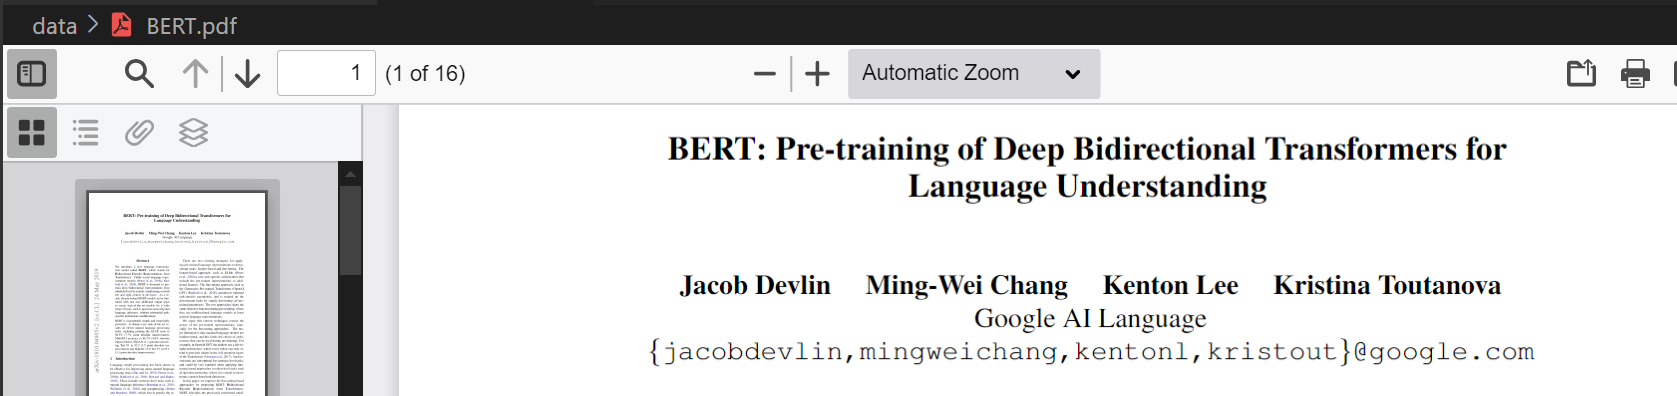

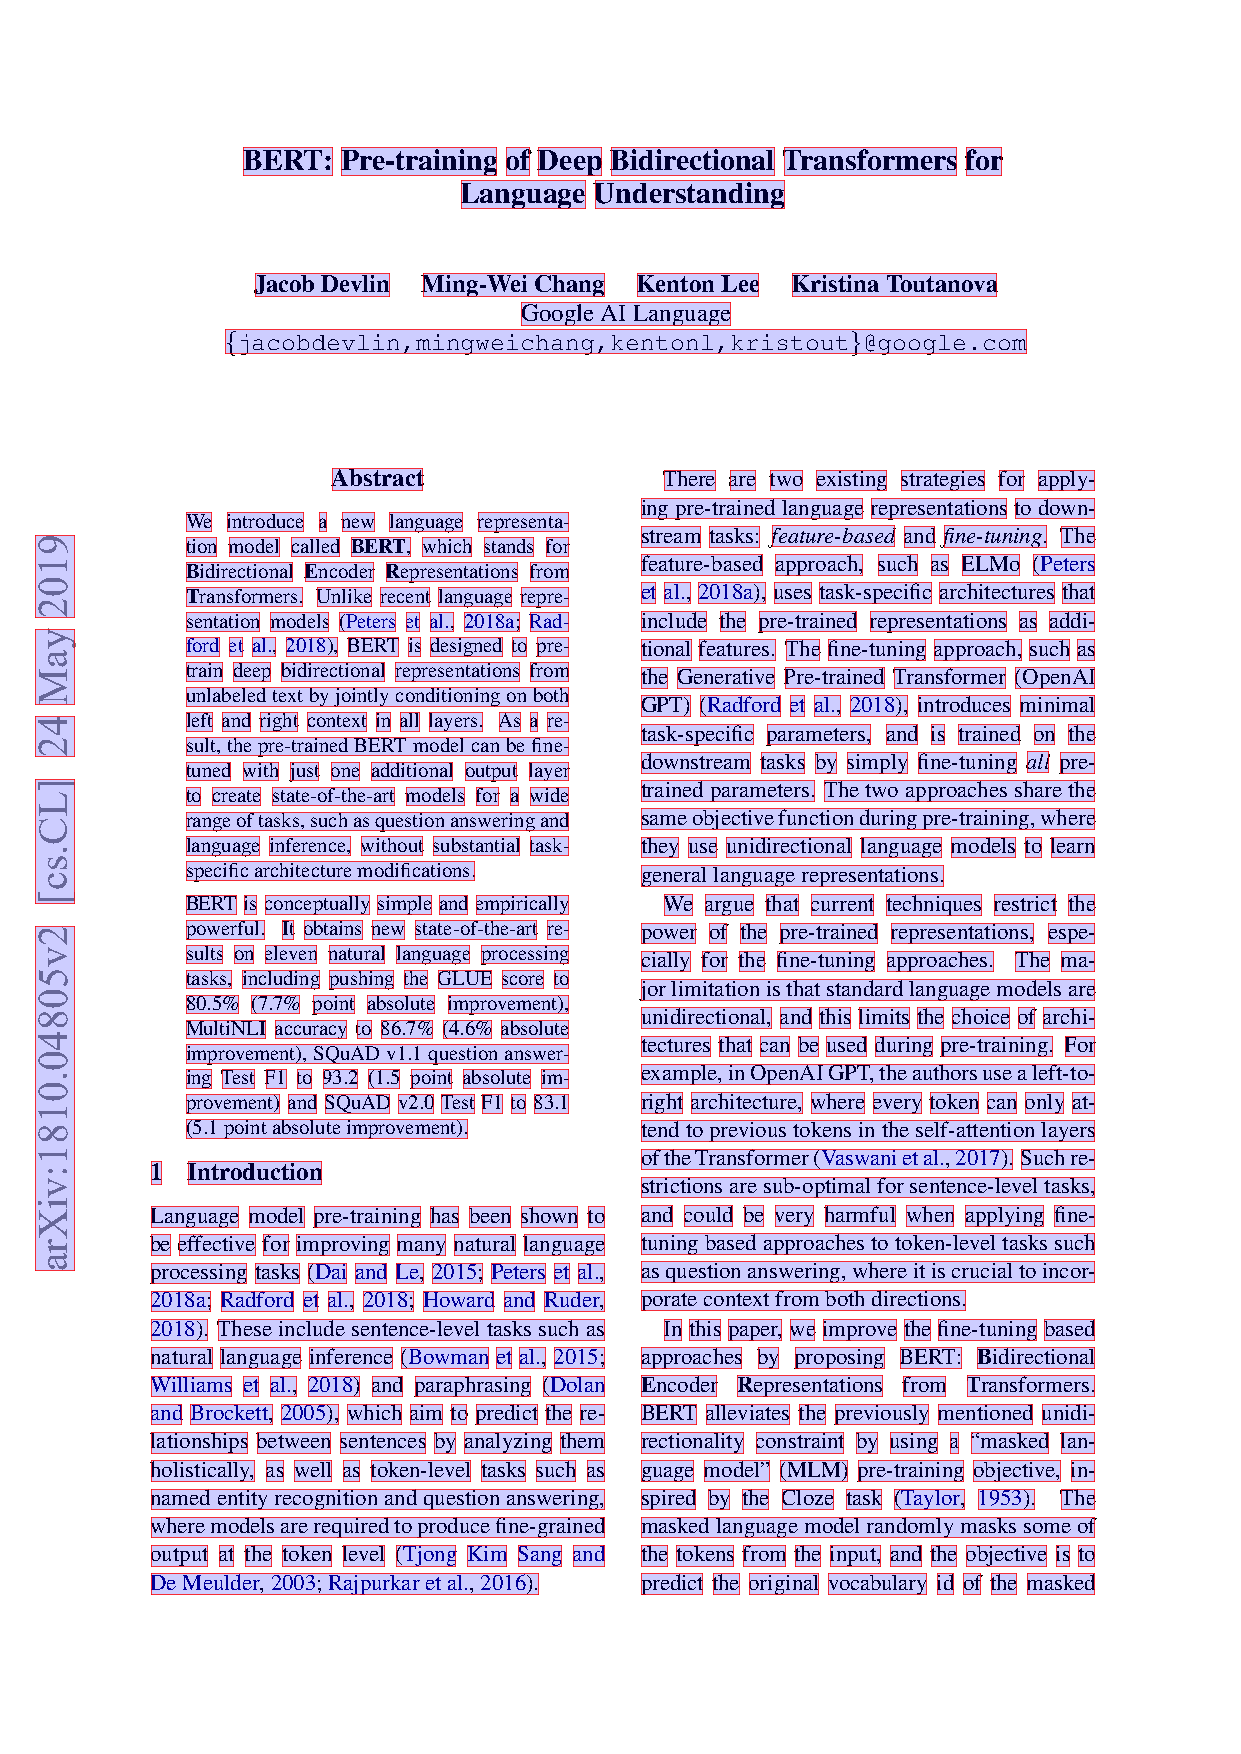

In [18]:
with pdfplumber.open(pdf_bert) as pdf:
    pages = pdf.pages
    im = pages[0].to_image(resolution=150)
    im.draw_rects(pages[0].extract_words())

im

#### with Langchain Document

In [19]:
import pdfplumber
from langchain_core.documents import Document

# Open the PDF file"
documents = []

with pdfplumber.open(pdf_bert) as pdf:
    dict_metadata = pdf.metadata

    # Iterate through all the pages in the PDF document
    for i, page in enumerate(pdf.pages):
        # Extract and print the text content of each page
        dict_metadata['page_no'] = i+1
        documents.append(Document(
            page_content=page.extract_text(),
            metadata=dict_metadata
        ))

> 추출된 메타데이터 확인 

In [45]:
documents[0].metadata

{'Author': '',
 'CreationDate': 'D:20190528000751Z',
 'Creator': 'LaTeX with hyperref package',
 'Keywords': '',
 'ModDate': 'D:20190528000751Z',
 'PTEX.Fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.17 (TeX Live 2016) kpathsea version 6.2.2',
 'Producer': 'pdfTeX-1.40.17',
 'Subject': '',
 'Title': '',
 'Trapped': 'False',
 'page_no': 1}

> 추출된 텍스트 확인 

In [46]:
print(documents[0].page_content[:300])

BERT: Pre-training of Deep Bidirectional Transformers for
Language Understanding
JacobDevlin Ming-WeiChang KentonLee KristinaToutanova
GoogleAILanguage
{jacobdevlin,mingweichang,kentonl,kristout}@google.com
Abstract There are two existing strategies for apply-
ingpre-trainedlanguage representations 


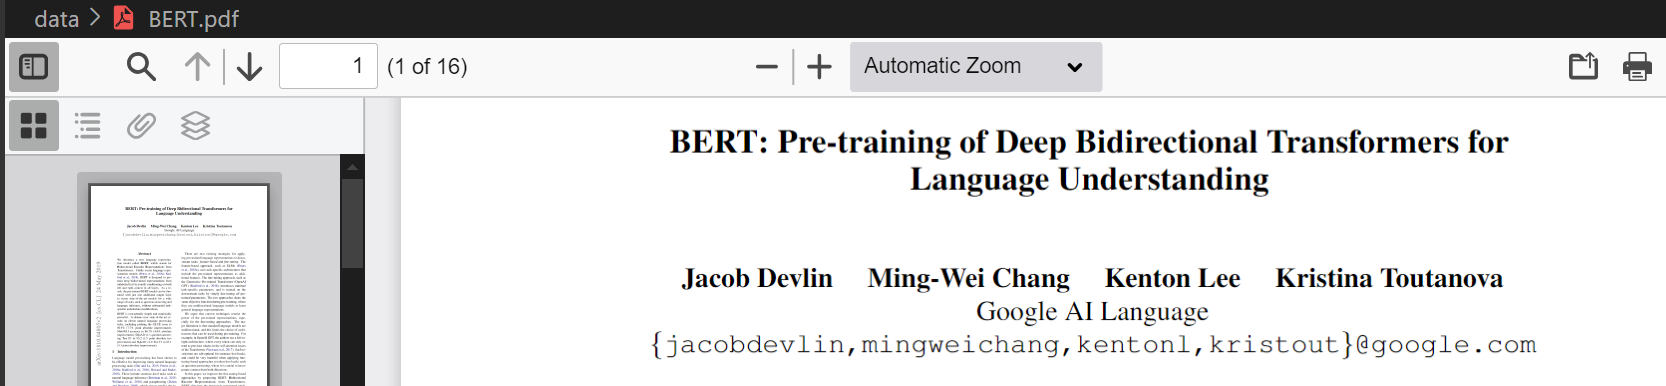